# Freight-Train 🚂
### "The trend is your friend" — ride what's moving across many markets. Does it pay, and why would you hold it?

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Crisis hedge?: Confirmed](https://img.shields.io/badge/Crisis_hedge%3F-Confirmed-8b949e?style=flat-square)

The oldest rule in systematic trading: buy what's been going up, sell what's been going down, across a whole basket of markets, and let the winners run. It's the engine of the **managed-futures** industry — *time-series momentum*, and unlike most folk rules it has serious academic backing (Moskowitz, Ooi & Pedersen 2012, across 58 futures and a century of data).

This is the desk's third idea from Kakushadze & Serur's *151 Trading Strategies* (strategy §10.4), and it's the most *grown-up* specimen yet: not an obvious mirage, but a real effect whose honest verdict is subtle. We prove the machinery on a synthetic universe where we bake a trend in (and a driftless null where there's nothing to ride), then run it on a real ETF basket — and find the standalone payoff is *faint and fading*, while the reason to actually hold it survives in a place the headline Sharpe never looks.

> 📓 **Plain-language layer.** The time-series-momentum *t*-stat, the alpha regression and the crisis-convexity test are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart is generated by the code beside it; the core runs on a **synthetic** tape with a *baked-in* trend, so the real-ETF numbers (from [`../docs/results.md`](../docs/results.md)) are a measurement. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # study root (trend_follow/ lives there)
sys.path.insert(0, os.path.abspath("../../.."))      # repo root, for quantlab
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9.5, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from trend_follow import data, trend, strategy, decompose, extension

# Offline synthetic universe: each asset's drift is a slow, persistent AR(1) (so past returns predict
# future ones -> time-series momentum). The NULL (trend_strength=0) is driftless noise. The real
# ETF-basket verdict is in ../docs/results.md.
panel,  truth = data.synthetic_panel(trend_strength=0.0006, seed=20)   # the trend tape
panel0, _     = data.synthetic_panel(trend_strength=0.0,    seed=20)   # the driftless null
print(f"{truth.n_assets} assets x {truth.n_bars} days | baked trend_strength={truth.trend_strength} | null=0")


12 assets x 5040 days | baked trend_strength=0.0006 | null=0


## The answer first 🎯

| What we asked | The honest answer |
|---|---|
| Does the trend predict the future? | 🟡 **Weakly, on this menu.** Real and strong in the academic cross-asset data; faint on our 14 equity-heavy ETFs (pooled *t* = **+1.5**). |
| Does it beat just holding the basket? | 🟡 **No, lately.** Standalone Sharpe **+0.29**, *below* the basket, and **decayed** (+0.53 → -0.08). |
| Then why hold it? | ⚪ **For the crash months.** When the basket loses **-7.83%/mo**, trend *earns* **+0.53%/mo** — the diversification you actually buy. |

> Desk shorthand: **Signal `WEAK` · Tradability `FRAGILE` · Crisis hedge? `CONFIRMED`** — a thin standalone edge whose real value is its behaviour in a storm.

## 1 · The claim 📣

Stated plainly: **what has trended tends to keep trending.** Take each market's own past-year return; if it's up, go long, if it's down, go short; size each position by the inverse of its volatility so no single market dominates; and diversify across dozens of them. The average of those timed bets is the trend-following return. On our synthetic universe we baked a slow, persistent drift into each asset — so the past genuinely predicts the future:

pooled time-series-momentum t = +3.5, hit rate 53%


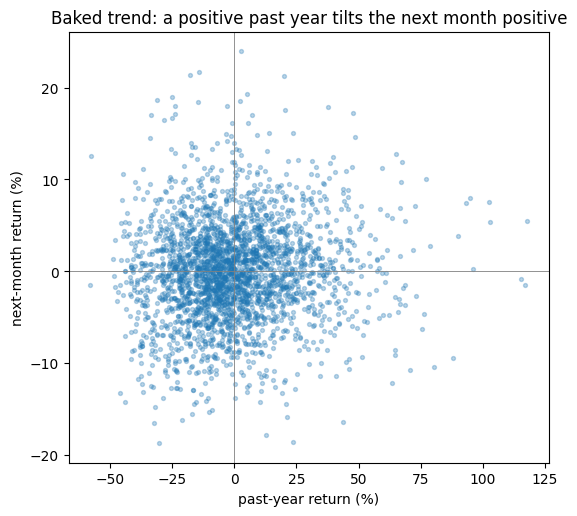

In [2]:
pr = trend.predictability(panel)
print(f"pooled time-series-momentum t = {pr['pooled_t']:+.1f}, hit rate {pr['hit_rate']:.0%}")
tr = trend.trailing_return(panel, 252).iloc[252::21].stack()
fwd = ((1+panel).rolling(21).apply(np.prod, raw=True).shift(-21)-1).iloc[252::21].stack()
d = pd.DataFrame({'past': tr, 'next': fwd}).dropna()
fig, ax = plt.subplots(figsize=(6.2,5.6))
ax.scatter(d['past']*100, d['next']*100, s=8, alpha=.3)
ax.axhline(0, c='grey', lw=.6); ax.axvline(0, c='grey', lw=.6)
ax.set_xlabel('past-year return (%)'); ax.set_ylabel('next-month return (%)')
ax.set_title('Baked trend: a positive past year tilts the next month positive')
plt.show()

## 2 · So what? 💰

If trends persist, you get a strategy with two prized traits. First, it's **diversifying**: it trades dozens of unrelated markets, long and short, so it isn't just dressed-up stock beta. Second — the big one — it tends to be **short a falling market** by the time a crash is under way, so it can *make money in exactly the months everything else is losing it*. That "crisis alpha" is why pensions and endowments pay for managed futures even when its standalone return is modest.

## 3 · How we'd know 🔬

Four checks, up front:

1. **Is the trend real?** Does a positive past-year return predict a positive next-month return, significantly?
2. **Does it beat holding the basket**, net of costs? (Costs should barely matter — the signal is slow.)
3. **Is it still working** — or has it decayed across the decades?
4. **The payoff shape:** does it earn in the basket's worst months? And the **null** — a driftless tape must yield nothing.

**Mirage/weak line:** the predictability is marginal and the standalone edge has faded — in which case the verdict hinges on whether the *diversification* survives.

## 4 · The teardown 🔧

### 4a · The trend is real — and the null is flat
Run the strategy on both synthetic tapes: the baked trend and the driftless null.

In [3]:
for label, p in [('trend', panel), ('driftless null', panel0)]:
    pr = trend.predictability(p); cmp = strategy.compare(p, cost_bps=2.0)
    print(f"{label:16s}: pooled t {pr['pooled_t']:+.1f} | TSMOM Sharpe {cmp['tsmom']['sharpe']:+.2f} "
          f"(gain vs basket {cmp['sharpe_gain']:+.2f}), turnover {cmp['turnover_ann']:.1f}x/yr")

trend           : pooled t +3.5 | TSMOM Sharpe +1.06 (gain vs basket +1.39), turnover 2.9x/yr


driftless null  : pooled t +0.7 | TSMOM Sharpe +0.08 (gain vs basket +0.29), turnover 3.6x/yr


### 4b · The equity curve, and the slow signal
Trend-following on the baked tape — note the *low turnover*: the signal moves over months, so you rebalance a few times a year, and costs barely bite (the opposite of a daily signal).

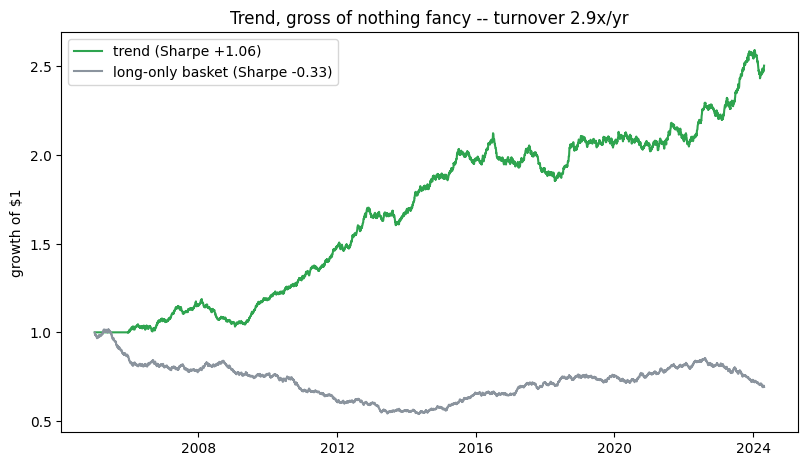

In [4]:
t = strategy.tsmom_returns(panel, cost_bps=2.0); b = strategy.long_only_basket(panel).reindex(t.index)
eq_t = (1+t).cumprod(); eq_b = (1+b).cumprod()
fig, ax = plt.subplots()
ax.plot(eq_t.index, eq_t.values, color='#2ea44f', label=f"trend (Sharpe {strategy.summary(t)['sharpe']:+.2f})")
ax.plot(eq_b.index, eq_b.values, color='#8b949e', label=f"long-only basket (Sharpe {strategy.summary(b)['sharpe']:+.2f})")
ax.legend(); ax.set_ylabel('growth of $1'); ax.set_title(f'Trend, gross of nothing fancy -- turnover {strategy.turnover_ann(panel):.1f}x/yr')
plt.show()

### 4c · The real tape — faint and fading
On a basket of 14 real ETFs (quoted from [`../docs/results.md`](../docs/results.md)):

- The trend is **weak here**: pooled *t* = **+1.5**, strategy Newey–West *t* = **+1.8** — at the edge of significance (the academic studies use 50+ cross-asset futures; our menu is equity-heavy and retail-accessible).
- Standalone it earns Sharpe **+0.29**, *below* just holding the basket (**+0.45**), and it has **decayed**: sub-sample Sharpe **+0.53 → +0.27 → -0.08**.
- Costs are *not* the issue (turnover only **3.3×/yr**) — unlike [Study 19](../../19-rubber-band/), this signal is slow.

So as a return engine, it's `WEAK`/`FRAGILE`. But we haven't looked where it actually earns its keep.

### 4d · Where it earns its keep — the crash months
Split months into the basket's *worst* and the rest, and compare. This is the whole reason to hold trend.

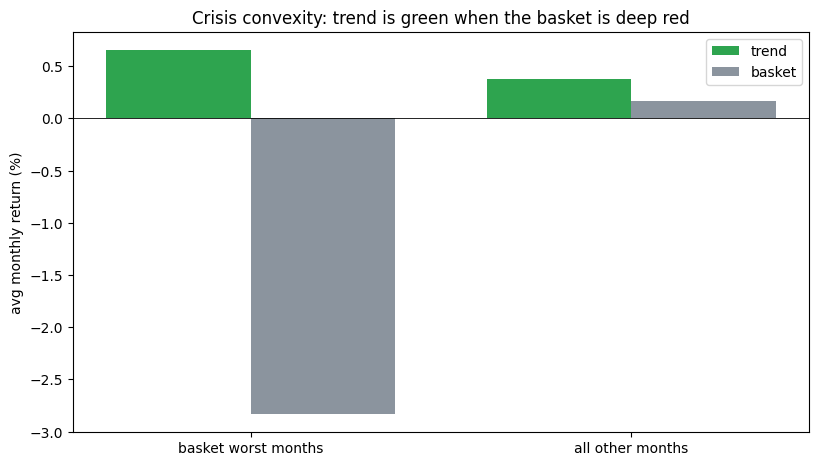

(Synthetic shown. On the REAL basket: trend +0.53%/mo vs basket -7.83%/mo in its worst 41 months.)


In [5]:
cc = extension.crisis_convexity(panel, cost_bps=2.0)
labels = ['basket worst months', 'all other months']
tsm = [cc['tsmom_crisis_mean_pct'], cc['tsmom_calm_mean_pct']]
bsk = [cc['basket_crisis_mean_pct'], cc['basket_calm_mean_pct']]
x = np.arange(2); w = 0.38
fig, ax = plt.subplots()
ax.bar(x-w/2, tsm, w, color='#2ea44f', label='trend'); ax.bar(x+w/2, bsk, w, color='#8b949e', label='basket')
ax.axhline(0, c='k', lw=.6); ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylabel('avg monthly return (%)'); ax.legend()
ax.set_title('Crisis convexity: trend is green when the basket is deep red')
plt.show()
print('(Synthetic shown. On the REAL basket: trend +0.53%/mo vs basket -7.83%/mo in its worst 41 months.)')

## 5 · The verdict 🧾

- **Real but weak here** — pooled *t* +1.5, strategy *t* +1.8; strong in the academic cross-asset data, faint on this equity-heavy ETF menu.
- **Decayed standalone** — Sharpe +0.53 → -0.08, below buy-and-hold.
- **But the convexity holds** — **+0.53%/mo** in the basket's worst months, basket beta **-0.05**.

> **Signal `WEAK` · Tradability `FRAGILE` · Crisis hedge? `CONFIRMED`.** Not a mirage and not a money-printer — a diversifier whose value lives in its shape, not its average.

## 6 · Could you trade it? 💸

- **Costs aren't the wall.** Turnover ~3.3×/yr; the break-even cost is far above anything realistic. This one *survives* execution — the rare case on this desk.
- **The standalone edge is thin and has decayed**, so you would *not* hold it for its own Sharpe.
- **You'd hold it as a sleeve.** Its job is the **+0.53%/mo** it makes when the rest of the book is down hardest — a negatively-correlated hedge you're *paid* (a little) to carry rather than paying an insurance premium for.

> Tradability **`FRAGILE`** standalone; **`CONFIRMED`** as a crisis hedge — the worked complement ([`../docs/extension.md`](../docs/extension.md)) makes the diversification case.

## 7 · Going further 🚪

- **The crisis-convexity test** (beat 7 of the quants notebook + [`../docs/extension.md`](../docs/extension.md)): trend's behaviour in the basket's worst months, the diversification a thin Sharpe hides.
- **A real cross-asset menu.** Our 14 ETFs are equity-heavy; the academic edge needs ~50 futures spanning rates, FX, commodities and equities. A broader basket should lift the standalone Sharpe and sharpen the convexity.
- **Faster/slower lookbacks & blends.** 1-, 3- and 12-month trends blended (and a vol-target overlay à la [Study 16](../../16-storm-shy/)) are how real CTAs run — does that rescue the standalone line?

PRs welcome — give trend the cross-asset menu it deserves, or pin when the equity-only version faded.